# 01 — Titanic EDA: profiling, cleaning and the data story

**Module 2, Part A.** This notebook is the *only* place the raw dataset is loaded. It:

1. loads Titanic once with `sns.load_dataset('titanic')` and immediately saves it as `titanic.csv` (the committed offline fallback that `02_modeling.ipynb` reads),
2. profiles it and handles missing values with the percentage-threshold rule,
3. runs univariate, bivariate and multivariate analysis, and
4. performs an exploratory z-score standardization check.

Charts are also saved to `figures/` as supporting artifacts. Every chart is followed by its written interpretation.

## 0. Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    # Verify HTTPS against the OS certificate store (needed where antivirus
    # software re-signs HTTPS traffic); harmless everywhere else.
    import truststore
    truststore.inject_into_ssl()
except ImportError:
    pass

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.width", 140)
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

def save(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png", dpi=110, bbox_inches="tight")

## 1. Load once, save the offline fallback, and profile

`sns.load_dataset` needs internet the first time (then it uses Seaborn's local cache). If it cannot be reached,
the committed `titanic.csv` is used instead. Either way the raw data is loaded **exactly once** in this module;
`02_modeling.ipynb` continues from the saved `titanic.csv` and never calls `sns.load_dataset` again.

In [2]:
try:
    df = sns.load_dataset("titanic")
    df.to_csv("titanic.csv", index=False)   # committed offline fallback
    print("Loaded from seaborn and saved -> titanic.csv")
except Exception as err:                     # no internet at grading time
    df = pd.read_csv("titanic.csv")
    print(f"sns.load_dataset failed ({type(err).__name__}); loaded the committed titanic.csv instead")

Loaded from seaborn and saved -> titanic.csv


In [3]:
print('Shape:', df.shape)
df.info()

Shape: (891, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [4]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df.describe(include=['object', 'category', 'bool'])

,sex,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891,889,891,891,891,203,889,891,891
unique,2,3,3,3,2,7,3,2,2
top,male,S,Third,man,True,C,Southampton,no,True
freq,577,644,491,537,537,59,644,549,537


In [6]:
missing_pct = (df.isna().mean() * 100).round(2)
missing_report = (missing_pct[missing_pct > 0]
                  .sort_values(ascending=False)
                  .to_frame("missing_%"))
missing_report["missing_count"] = df[missing_report.index].isna().sum()
missing_report

,missing_%,missing_count
deck,77.22,688
age,19.87,177
embarked,0.22,2
embark_town,0.22,2


In [7]:
balance = df["survived"].value_counts(normalize=True).mul(100).round(1)
print("Class balance of the target (survived):")
print(balance.rename({0: "0 = did not survive", 1: "1 = survived"}).to_string())

Class balance of the target (survived):
survived
0 = did not survive    61.6
1 = survived           38.4


**Profile summary.**

- **Size and types.** 891 passengers × 15 columns: 6 numeric (`survived`, `pclass`, `age`, `sibsp`, `parch`,
  `fare`), 2 boolean flags (`adult_male`, `alone`), and text or categorical columns (`sex`, `embarked`, `class`,
  `who`, `deck`, `embark_town`, `alive`).
- **Missing values.** Four columns have gaps: **`deck` 77.22 %** (688 rows), **`age` 19.87 %** (177 rows),
  **`embarked` 0.22 %** (2 rows) and **`embark_town` 0.22 %** (2 rows).
- **Target balance.** **61.6 % did not survive and 38.4 % survived.** This moderate imbalance matters later
  for the stratified split and for the imbalance experiment.
- **Redundant columns.** `class`, `who`, `alive` and `embark_town` are re-encodings of `pclass`,
  `sex`/`age`, `survived` and `embarked`. `alive` in particular is simply the target in words.

## 2. Missing-value handling — the threshold rule

| Missing share | Rule |
|---|---|
| under 5 % | drop the affected rows |
| 5 % – 30 % | impute |
| far above 30 % | imputation unreliable → drop the column **or** encode "missing" as its own category |

In [8]:
clean = df.copy()

# embarked (0.22 %) and embark_town (0.22 %): under 5 % -> drop those rows.
# They are missing on the same 2 passengers, so this removes exactly 2 rows.
rows_before = len(clean)
clean = clean.dropna(subset=["embarked", "embark_town"])
print(f"Dropped {rows_before - len(clean)} rows missing embarked/embark_town")

# age (19.87 %): between 5 % and 30 % -> impute with the median age of the
# passenger's own sex x pclass group.
age_medians = clean.groupby(["sex", "pclass"])["age"].median().round(1)
print("\nMedian age used for imputation, by sex and pclass:")
print(age_medians.unstack().to_string())
clean["age"] = clean["age"].fillna(clean.groupby(["sex", "pclass"])["age"].transform("median"))

# deck (77.22 %): far too high to impute -> keep it, with "Unknown" as its own category.
clean["deck"] = clean["deck"].astype("object").fillna("Unknown")

print("\nRemaining missing values:", int(clean.isna().sum().sum()))
print("Shape after cleaning:", clean.shape)

Dropped 2 rows missing embarked/embark_town

Median age used for imputation, by sex and pclass:
pclass     1     2     3
sex                     
female  35.0  28.0  21.5
male    40.0  30.0  25.0

Remaining missing values: 0
Shape after cleaning: (889, 15)


In [9]:
# Evidence for the deck decision: is "deck missing" informative about survival and class?
deck_known = clean["deck"] != "Unknown"
print("Survival rate, deck known  :", round(clean.loc[deck_known, "survived"].mean() * 100, 1), "%")
print("Survival rate, deck Unknown:", round(clean.loc[~deck_known, "survived"].mean() * 100, 1), "%")
print("\nShare of each class with an Unknown deck (%):")
print((clean.groupby("pclass")["deck"].apply(lambda s: (s == "Unknown").mean() * 100)).round(1).to_string())

Survival rate, deck known  : 66.7 %
Survival rate, deck Unknown: 29.9 %

Share of each class with an Unknown deck (%):
pclass
1    19.2
2    91.3
3    97.6


**Missing-value decisions, one per affected column, following the threshold rule:**

| Column | Measured missing | Band | Strategy |
|---|---|---|---|
| `embarked` | **0.22 %** (2 rows) | under 5 % | **Drop those rows** |
| `embark_town` | **0.22 %** (2 rows) | under 5 % | **Drop those rows**. They are the same 2 passengers as `embarked`, so only 2 rows are removed in total (891 → 889). |
| `age` | **19.87 %** (177 rows) | 5 %–30 % | **Impute** with the median age of the passenger's own `sex` × `pclass` group |
| `deck` | **77.22 %** (688 rows) | far above 30 % | **Encode "Unknown" as its own category** |

**Why group medians for `age`.** Age differs a lot between groups. The group medians range from 21.5
(third-class women) to 40.0 (first-class men). One global median (28) would pull every group towards the
middle; the group median keeps each passenger's likely age realistic. The median rather than the mean is used
because age is right-skewed.

**Why keep `deck` as "Unknown" instead of dropping the column.** With 77 % missing, any imputed deck letter would
be mostly invented, so imputation is ruled out. But the missingness itself is **informative**:

- Survival is **66.7 %** for passengers with a known deck, against **29.9 %** when the deck is unknown.
- An unknown deck is concentrated in the lower classes: 19.2 % of 1st class, 91.3 % of 2nd class and 97.6 % of
  3rd class.

In other words, "no recorded cabin" is a signal in itself, because cabin records mostly survived for
first-class passengers. Dropping the column would throw that signal away, while an explicit "Unknown" category
keeps it without inventing values.

## 3. Univariate analysis — `age` and `fare`

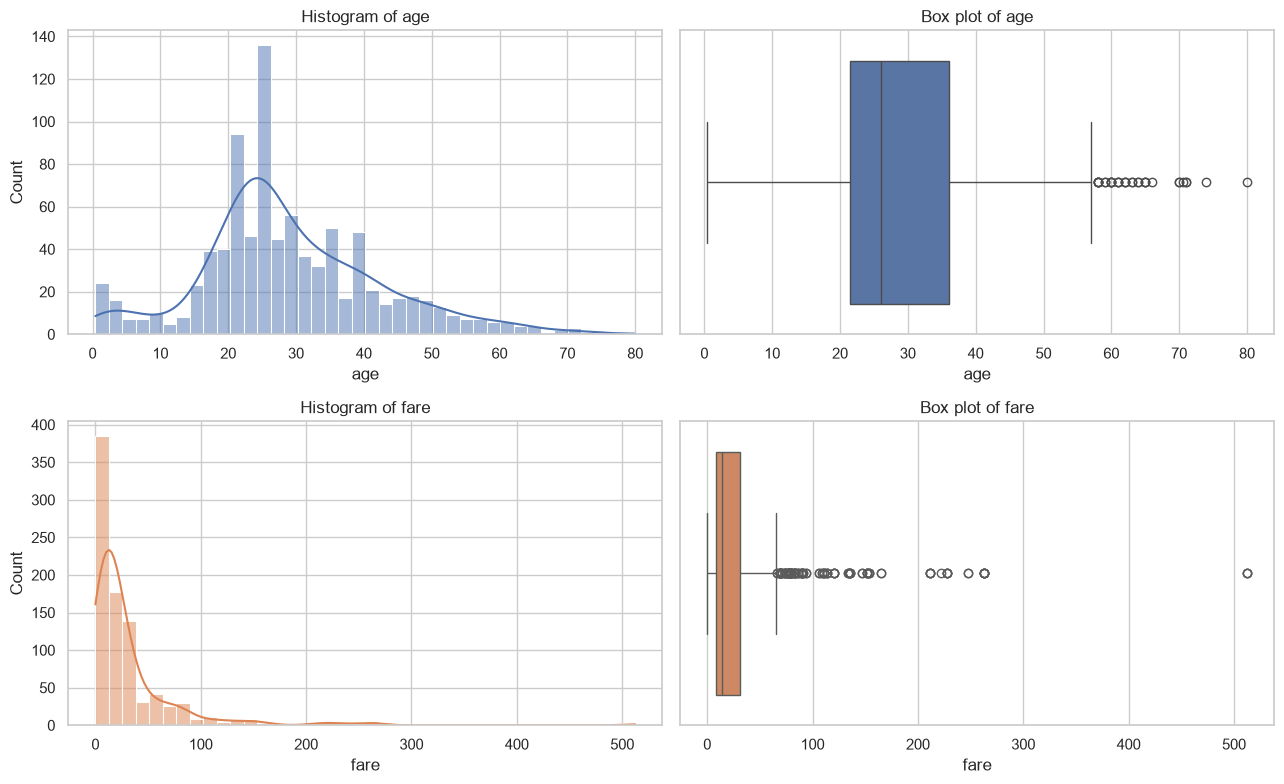

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for row, col, color in [(0, "age", "#4C72B0"), (1, "fare", "#DD8452")]:
    sns.histplot(clean[col], bins=40, kde=True, color=color, ax=axes[row, 0])
    axes[row, 0].set_title(f"Histogram of {col}")
    sns.boxplot(x=clean[col], color=color, ax=axes[row, 1])
    axes[row, 1].set_title(f"Box plot of {col}")
fig.tight_layout()
save(fig, "01_age_fare_hist_box")
plt.show()

In [11]:
def iqr_outliers(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n = int(((s < low) | (s > high)).sum())
    return {"Q1": q1, "Q3": q3, "IQR": iqr, "lower_fence": low, "upper_fence": high,
            "n_outliers": n, "outlier_%": round(n / len(s) * 100, 2)}

outliers = pd.DataFrame({c: iqr_outliers(clean[c]) for c in ["age", "fare"]}).T
outliers["n_outliers"] = outliers["n_outliers"].astype(int)
print("IQR outliers on the cleaned data (the data used for all later analysis):")
print(outliers.round(2).to_string())

# For transparency: the same rule on the raw, un-imputed values
raw_counts = {c: iqr_outliers(df[c].dropna())["n_outliers"] for c in ["age", "fare"]}
print("\nSame rule on the raw data (missing ages ignored):", raw_counts)

IQR outliers on the cleaned data (the data used for all later analysis):
        Q1    Q3   IQR  lower_fence  upper_fence  n_outliers  outlier_%
age   21.5  36.0  14.5        -0.25        57.75          32       3.60
fare   7.9  31.0  23.1       -26.76        65.66         114      12.82

Same rule on the raw data (missing ages ignored): {'age': 11, 'fare': 116}


In [12]:
fare_mean, fare_median = clean["fare"].mean(), clean["fare"].median()
fare_mode = clean["fare"].mode()[0]
print(f"fare mean   = {fare_mean:.2f}")
print(f"fare median = {fare_median:.2f}")
print(f"fare mode   = {fare_mode:.2f}")
print(f"skewness    = {clean['fare'].skew():.2f}")
print("Ordering: mean > median > mode" if fare_mean > fare_median > fare_mode else "Ordering differs")

fare mean   = 32.10
fare median = 14.45
fare mode   = 8.05
skewness    = 4.80
Ordering: mean > median > mode


**Univariate findings.**

- **`age`.** A single peak in the 20s, with a smaller bump of young children. The spike near 25 is partly
  created by the group-median imputation, which gave 177 passengers one of six median values.
  - IQR fences: [−0.25, 57.75]. **32 outliers (3.6 %)**, all elderly passengers above 57.75.
  - Measured before imputation, the same rule finds **11**. Imputation piles values into the middle, which
    narrows the IQR and so flags more of the older passengers.
  - These are genuine ages, not errors, so they are kept.
- **`fare`.** IQR fences: [−26.76, 65.66]. **114 outliers (12.8 %)** on the cleaned data (116 on the raw data),
  all expensive tickets. They are real first-class fares, up to 512.33, so they are kept as well.
- **Skewness of `fare`.** **mean (32.10) > median (14.45) > mode (8.05)**, which is the textbook ordering of a
  **right-skewed** distribution. A long tail of a few very expensive tickets pulls the mean far above the typical
  fare, while the most common ticket is a cheap third-class fare. The sample skewness of 4.80 confirms it.

## 4. Bivariate analysis — survival rates with boolean masks

Each rate below is computed as `clean.loc[mask, "survived"].mean()` with an explicit boolean mask,
combining conditions with `&` (and) and `|` (or).

In [13]:
def rate(mask):
    return round(clean.loc[mask, "survived"].mean() * 100, 1)

# (a) by sex
by_sex = pd.Series({s: rate(clean["sex"] == s) for s in ["female", "male"]}, name="survival_%")
print("(a) Survival rate by sex (%)\n", by_sex.to_string(), "\n")

# (b) by pclass
by_class = pd.Series({p: rate(clean["pclass"] == p) for p in [1, 2, 3]}, name="survival_%")
print("(b) Survival rate by pclass (%)\n", by_class.to_string(), "\n")

# (c) by sex AND pclass together, using & masks
by_sex_class = pd.DataFrame(
    {p: {s: rate((clean["sex"] == s) & (clean["pclass"] == p)) for s in ["female", "male"]}
     for p in [1, 2, 3]}
)
by_sex_class.columns = [f"pclass {p}" for p in by_sex_class.columns]
print("(c) Survival rate by sex & pclass (%)\n", by_sex_class.to_string(), "\n")

# An | (or) combination: the "women and children first" group vs everyone else
women_or_children = (clean["sex"] == "female") | (clean["age"] < 16)
print(f"Women OR children under 16: {rate(women_or_children)} %  "
      f"(n={int(women_or_children.sum())})")
print(f"Everyone else (adult men) : {rate(~women_or_children)} %  "
      f"(n={int((~women_or_children).sum())})")

(a) Survival rate by sex (%)
 female    74.0
male      18.9 

(b) Survival rate by pclass (%)
 1    62.6
2    47.3
3    24.2 

(c) Survival rate by sex & pclass (%)
         pclass 1  pclass 2  pclass 3
female      96.7      92.1      50.0
male        36.9      15.7      13.5 

Women OR children under 16: 71.6 %  (n=352)
Everyone else (adult men) : 16.4 %  (n=537)


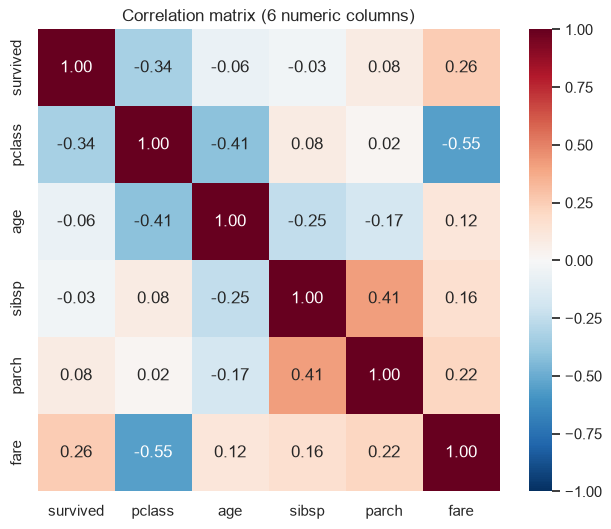

r  abs_r
pclass   fare   -0.548  0.548
sibsp    parch   0.415  0.415
pclass   age    -0.411  0.411
survived pclass -0.336  0.336
         fare    0.255  0.255
age      sibsp  -0.249  0.249
parch    fare    0.218  0.218
age      parch  -0.175  0.175
sibsp    fare    0.161  0.161
age      fare    0.120  0.120
survived parch   0.083  0.083
pclass   sibsp   0.082  0.082
survived age    -0.064  0.064
         sibsp  -0.034  0.034
pclass   parch   0.017  0.017

In [14]:
corr_cols = ["survived", "pclass", "age", "sibsp", "parch", "fare"]   # adult_male, alone excluded
corr = clean[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title("Correlation matrix (6 numeric columns)")
save(fig, "02_correlation_heatmap")
plt.show()

# Rank every off-diagonal pair (upper triangle only, so each pair appears once) by |r|
upper = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
pairs = (upper.stack().rename("r").to_frame()
         .assign(abs_r=lambda d: d["r"].abs())
         .sort_values("abs_r", ascending=False))
pairs.round(3)

**Survival rates, computed with boolean masks:**

- **(a) By sex.** Women **74.0 %**, men **18.9 %**.
- **(b) By class.** 1st **62.6 %**, 2nd **47.3 %**, 3rd **24.2 %**.
- **(c) By sex and class.** Women: 96.7 % / 92.1 % / 50.0 % across 1st / 2nd / 3rd class. Men: 36.9 % / 15.7 % /
  13.5 %.
- **An `|` (or) mask.** "Women **or** children under 16" survived at **71.6 %**, against **16.4 %** for adult men.

Sex is the dominant factor, and class compounds it. Nearly every woman in 1st and 2nd class survived, while even
a 1st-class man had a lower survival chance than a 3rd-class woman.

**Correlation heatmap.** It covers the six specified columns only; `adult_male` and `alone` are excluded as
derived flags. All 15 off-diagonal pairs are ranked by |r| in the table above. The two strongest are:

1. **`pclass`–`fare`, r = −0.548.** A higher class *number* (a cheaper class) goes with a lower fare. This is
   the strongest relationship in the data, and it is exactly what you would expect: the ticket price largely
   *is* the class. It also warns that `fare` and `pclass` carry overlapping information.
2. **`sibsp`–`parch`, r = +0.415.** Passengers travelling with siblings or spouses also tend to travel with
   parents or children, because both columns count members of the same family groups.

For the target itself, `survived` correlates most with `pclass` (r = −0.336) and `fare` (r = +0.255).
Its linear correlation with `age` is weak (−0.064). Age matters mainly at the young end, which a straight-line
correlation cannot capture (see Chart 2).

## 5. Multivariate data story — who survived, and why?

Five charts, each followed by its interpretation. Together they argue that survival was decided mainly by
**sex**, then **class**, with **age** (children) and **family size** as secondary factors, and that fare matters
mostly because it is a proxy for class.

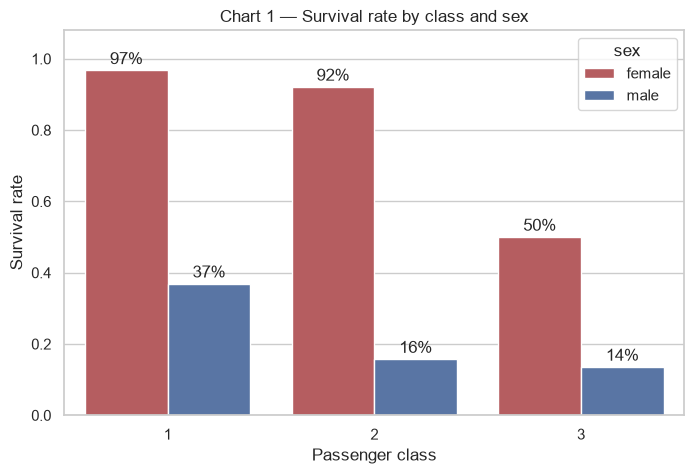

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=clean, x="pclass", y="survived", hue="sex", errorbar=None,
            palette={"female": "#C44E52", "male": "#4C72B0"}, ax=ax)
for container in ax.containers:
    ax.bar_label(container, labels=[f"{v*100:.0f}%" for v in container.datavalues], padding=2)
ax.set(title="Chart 1 — Survival rate by class and sex", xlabel="Passenger class",
       ylabel="Survival rate", ylim=(0, 1.08))
save(fig, "03_story_class_sex")
plt.show()

**Chart 1 interpretation.** This chart carries the main argument: **sex decided survival first, and class second**.

- **Women:** 97 % and 92 % survived in 1st and 2nd class, but only 50 % in 3rd class.
- **Men:** only 37 % survived even in 1st class, falling to 16 % and 14 % in 2nd and 3rd.

The "women and children first" loading policy explains the sex gap. Class explains the rest, because
first-class cabins were closer to the boat deck and were reached first.

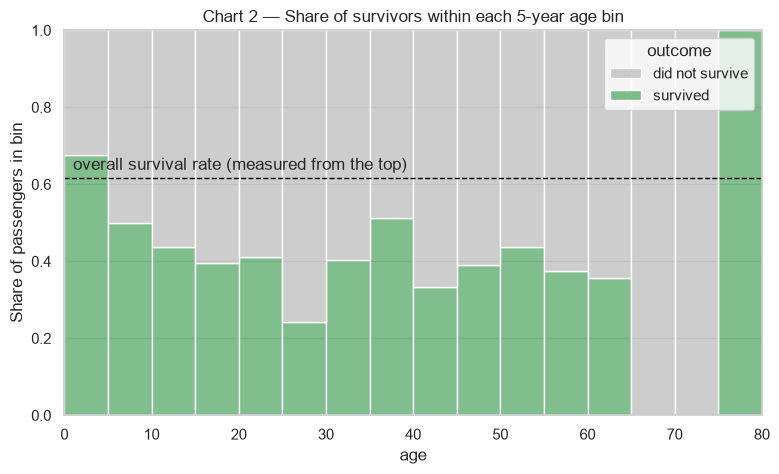

       survival_rate    n
age                      
0-12           0.580   69
13-18          0.429   70
19-30          0.321  417
31-50          0.426  270
51-80          0.333   63


In [16]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_df = clean.assign(outcome=clean["survived"].map({0: "did not survive", 1: "survived"}))
sns.histplot(data=plot_df, x="age", hue="outcome", hue_order=["did not survive", "survived"],
             binwidth=5, binrange=(0, 80), multiple="fill",
             palette={"did not survive": "#BDBDBD", "survived": "#55A868"}, ax=ax)
ax.axhline(1 - clean["survived"].mean(), color="black", ls="--", lw=1)
ax.text(1, 1 - clean["survived"].mean() + 0.02, "overall survival rate (measured from the top)")
ax.set(title="Chart 2 — Share of survivors within each 5-year age bin", ylabel="Share of passengers in bin")
save(fig, "04_story_age")
plt.show()

age_bands = pd.cut(clean["age"], bins=[0, 12, 18, 30, 50, 80],
                   labels=["0-12", "13-18", "19-30", "31-50", "51-80"])
print(clean.groupby(age_bands, observed=True)["survived"].agg(["mean", "size"])
      .rename(columns={"mean": "survival_rate", "size": "n"}).round(3).to_string())

**Chart 2 interpretation.** Each bar shows the survivor share (green) within a 5-year age band. The dashed line is
the overall survival rate, read downward from the top.

- **Children stand out.** 0–5-year-olds are the only band well above average: about 68 % survived, and the
  0–12 band as a whole survived at 58 %.
- **Young adults fared worst.** The 19–30 band, which is dominated by third-class men, survived at only 32 %.
- **Older passengers.** The 65–75 bands show 0 %, and the single 80-year-old survived. These bands contain very
  few passengers, so they should not be over-read.

This is why `age` has a near-zero linear correlation with survival yet still matters: its effect is
concentrated at the youngest ages.

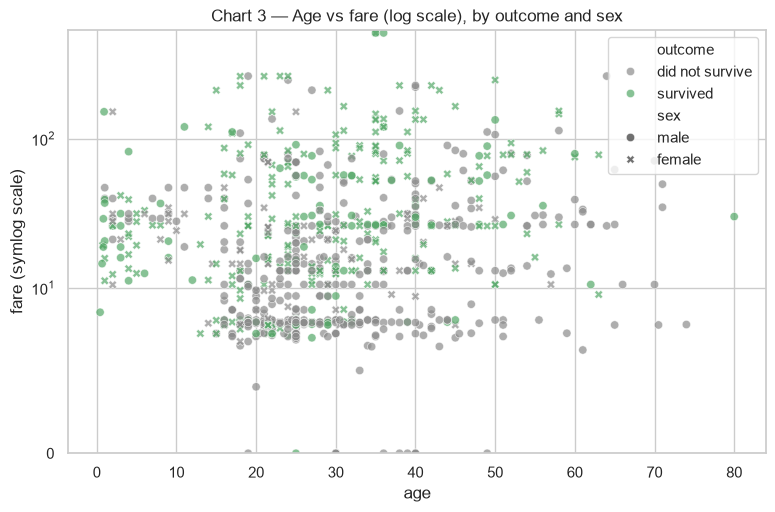

survived
median fare, died        10.5
median fare, survived    26.0


In [17]:
plot_df = clean.assign(outcome=clean["survived"].map({0: "did not survive", 1: "survived"}))
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.scatterplot(data=plot_df, x="age", y="fare", hue="outcome", style="sex", alpha=0.7,
                palette={"did not survive": "#8C8C8C", "survived": "#55A868"}, ax=ax)
ax.set_yscale("symlog", linthresh=10)
ax.set_ylim(bottom=0)
ax.set(title="Chart 3 — Age vs fare (log scale), by outcome and sex", ylabel="fare (symlog scale)")
save(fig, "05_story_age_fare_scatter")
plt.show()

print(clean.groupby("survived")["fare"].median().rename({0: "median fare, died", 1: "median fare, survived"}).round(2).to_string())

**Chart 3 interpretation.** Fare is plotted on a log scale so that cheap and expensive tickets are both visible.

- **Survivors (green) cluster in the upper band of fares.** The median fare of survivors is **26.0**, against
  **10.5** for those who died.
- **Men (circles) in the dense low-fare band below 15 are overwhelmingly grey:** 88 % of them did not survive.
- **Survivors at low fares are mostly women (crosses) or children:** 69 % of the survivors who paid under 15.

So fare and sex combine: a high fare helps, but being female helps far more at every fare level.

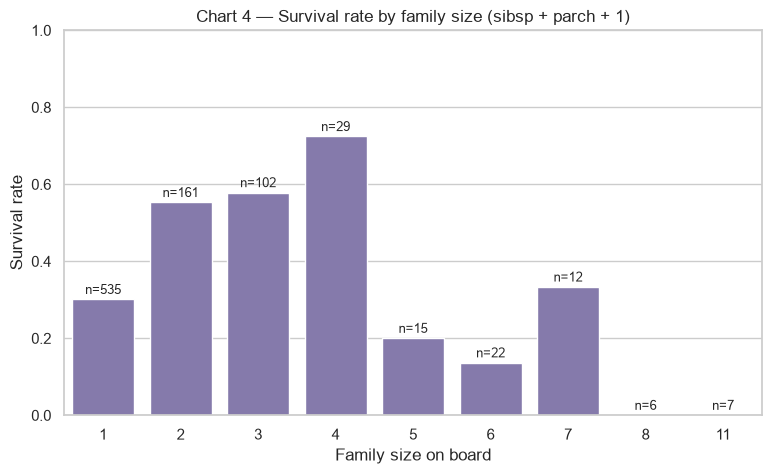

In [18]:
clean_story = clean.assign(family_size=clean["sibsp"] + clean["parch"] + 1)
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=clean_story, x="family_size", y="survived", errorbar=None, color="#8172B3", ax=ax)
counts = clean_story["family_size"].value_counts().sort_index()
ax.bar_label(ax.containers[0], labels=[f"n={counts[i]}" for i in counts.index], padding=2, fontsize=9)
ax.set(title="Chart 4 — Survival rate by family size (sibsp + parch + 1)",
       xlabel="Family size on board", ylabel="Survival rate", ylim=(0, 1))
save(fig, "06_story_family_size")
plt.show()

**Chart 4 interpretation.** Family size (sibsp + parch + 1) has a clear "sweet spot":

- **Alone:** passengers travelling alone (n = 535, the majority) survived at only about 30 %.
- **Small families:** families of 2–4 did best, at about 55 %, 58 % and 72 %.
- **Large families:** families of 5 or more collapsed to 0–33 %, and every member of the 8- and 11-person
  families died.

Small families likely helped each other and included women and children who were given priority. Large families
were mostly in third class (87 % of families of 5 or more) and hard to keep together. Solo travellers were
disproportionately adult men (77 %, against 60 % of all passengers).

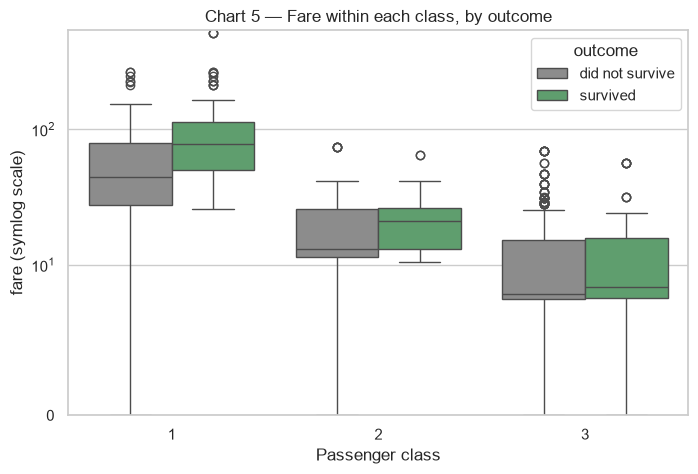

survived  median fare, died  median fare, survived
pclass                                            
1                     44.75                  77.34
2                     13.00                  21.00
3                      8.05                   8.52


In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=plot_df, x="pclass", y="fare", hue="outcome",
            hue_order=["did not survive", "survived"],
            palette={"did not survive": "#8C8C8C", "survived": "#55A868"}, ax=ax)
ax.set_yscale("symlog", linthresh=10)
ax.set_ylim(bottom=0)
ax.set(title="Chart 5 — Fare within each class, by outcome", xlabel="Passenger class", ylabel="fare (symlog scale)")
save(fig, "07_story_fare_by_class")
plt.show()

print(clean.groupby(["pclass", "survived"])["fare"].median().unstack().round(2)
      .rename(columns={0: "median fare, died", 1: "median fare, survived"}).to_string())

**Chart 5 interpretation.** This chart asks whether fare matters *beyond* class.

- **In 1st class, survivors paid clearly more.** The median fare was 77.34 for survivors against 44.75 for those
  who died, which suggests better (higher-deck) cabins within first class.
- **In 2nd class the gap is smaller:** 21.00 against 13.00.
- **In 3rd class there is almost none:** 8.52 against 8.05.

So fare's link with survival is mostly its link with class, plus a real within-class effect only at the top of
the market. This completes the story: **sex first, then class (with fare as its proxy), then being a young child
or part of a small family**.

## 6. Exploratory z-score standardization check (EDA only)

`z = (x − mean) / std` applied to `age` and `fare` on the full cleaned DataFrame. This is **only a sanity
check**: it is not used by the modeling notebook, whose `StandardScaler` is fitted on the training split only.

      mean_before  std_before  mean_after  std_after
age       29.0654     13.2702         0.0        1.0
fare      32.0967     49.6975         0.0        1.0


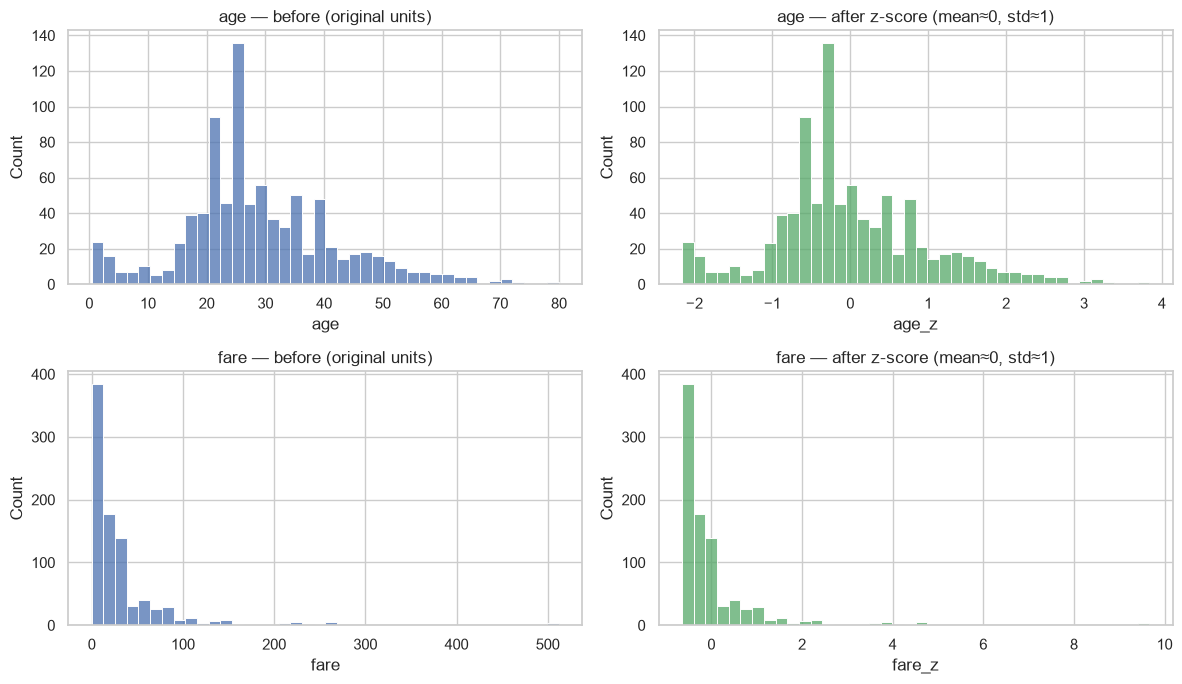

In [20]:
z = pd.DataFrame({
    f"{c}_z": (clean[c] - clean[c].mean()) / clean[c].std() for c in ["age", "fare"]
})
summary = pd.DataFrame({
    "mean_before": clean[["age", "fare"]].mean().values,
    "std_before":  clean[["age", "fare"]].std().values,
    "mean_after":  z.mean().values,
    "std_after":   z.std().values,
}, index=["age", "fare"])
print(summary.round(4).to_string())

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for row, c in enumerate(["age", "fare"]):
    sns.histplot(clean[c], bins=40, ax=axes[row, 0], color="#4C72B0")
    axes[row, 0].set_title(f"{c} — before (original units)")
    sns.histplot(z[f"{c}_z"], bins=40, ax=axes[row, 1], color="#55A868")
    axes[row, 1].set_title(f"{c} — after z-score (mean≈0, std≈1)")
fig.tight_layout()
save(fig, "08_zscore_before_after")
plt.show()

**Standardization check.** Before scaling, `age` has mean 29.07 and std 13.27, and `fare` has mean 32.10 and
std 49.70, so the two columns are on very different scales. After applying z = (x − mean) / std, **both have
mean 0.0000 and standard deviation 1.0000**.

The before/after histograms have identical shapes, because the transform only shifts and rescales the values. In
particular, `fare` stays right-skewed: standardizing does not remove skew, it only puts the columns on a common
scale.

As required, this check is EDA-only. The modeling notebook fits its own `StandardScaler` on the training split
alone.

## Summary — handover to `02_modeling.ipynb`

- **Load and save.** The raw dataset was loaded **once** and saved as `titanic.csv` (committed, 891 rows).
  `02_modeling.ipynb` reads that file and applies the same row-level rule: it drops the 2 rows missing
  `embarked`, which fall under 5 %.
- **Leakage-safe imputation.** Age imputation and scaling are **re-done inside the modeling pipeline, fitted on
  the training split only**. The group medians used here were computed on the full dataset, which is fine for
  description but would leak test-set information into a model.
- **Features to model.** The EDA points to `sex`, `pclass`, `age`, `fare` and family size (`sibsp`, `parch`),
  with `embarked` as a minor extra.
- **Columns to exclude.** `alive` must never be used, because it *is* the target. `class`, `who`, `adult_male`,
  `embark_town` and `alone` only re-encode other columns.